<a href="https://www.kaggle.com/code/kaushikfreddyregalla/06-grad-cam-error-analysis?scriptVersionId=325268406" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 06 — Grad-CAM & Error Analysis
Hand Gesture Recognition | Kaushik Reddy Ragalla

In [1]:
import os, sys, io, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
_stderr = sys.stderr; sys.stderr = io.StringIO()
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
sys.stderr = _stderr

os.makedirs('figures', exist_ok=True)
CLASS_NAMES = ['01_palm','02_l','03_fist','04_fist_moved','05_thumb',
               '06_index','07_ok','08_palm_moved','09_c','10_down']
NUM_CLASSES = 10
tf.random.set_seed(42)
np.random.seed(42)

# ── Step 1: Find X_test.npy ──────────────────────────────────────────────────
NPY_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'X_test.npy' in files:
        NPY_DIR = root
        break
print(f'NPY_DIR = {NPY_DIR}')
assert NPY_DIR is not None, 'X_test.npy not found'

X_test     = np.load(os.path.join(NPY_DIR, 'X_test.npy'))
y_test     = np.load(os.path.join(NPY_DIR, 'y_test.npy'))
X_test_rgb = np.repeat(X_test, 3, axis=-1)
y_true     = np.argmax(y_test, axis=1)
print(f'X_test shape: {X_test.shape}')

# ── Step 2: Find best_mobilenet.keras ────────────────────────────────────────
MOB_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'best_mobilenet.keras' in files:
        MOB_PATH = os.path.join(root, 'best_mobilenet.keras')
        break
print(f'MOB_PATH = {MOB_PATH}')
assert MOB_PATH is not None, 'best_mobilenet.keras not found'

mobilenet_model = tf.keras.models.load_model(MOB_PATH)
y_prob_mob = mobilenet_model.predict(X_test_rgb, verbose=0)
y_pred_mob = np.argmax(y_prob_mob, axis=1)
print(f'Accuracy: {(y_true==y_pred_mob).mean()*100:.2f}%')


E0000 00:00:1780873433.942870      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780873433.993649      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780873434.383758      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780873434.383796      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780873434.383798      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780873434.383801      25 computation_placer.cc:177] computation placer already registered. Please check linka

NPY_DIR = /kaggle/input/notebooks/kaushikfreddyregalla/02-preprocessing-data-augmentation
X_test shape: (3000, 128, 128, 1)
MOB_PATH = /kaggle/input/notebooks/kaushikfreddyregalla/04-transfer-learning-mobilenetv2-vgg16/best_mobilenet.keras


I0000 00:00:1780873450.546697      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780873450.552613      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780873455.865087      71 service.cc:152] XLA service 0x7e09e804fc40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780873455.865127      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780873455.865130      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780873456.502913      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780873466.180692      71 device_compiler.h:188] Compiled clust

Accuracy: 99.93%


In [2]:
# ── SmoothGrad saliency maps ──────────────────────────────────────────────────

def make_saliency_map(img_array, model, pred_index=None, n_samples=20, noise=0.1):
    img = tf.cast(img_array, tf.float32)
    sigma = noise * (tf.reduce_max(img) - tf.reduce_min(img))
    total_grads = tf.zeros_like(img)
    for _ in range(n_samples):
        noisy = img + tf.random.normal(tf.shape(img), stddev=sigma)
        with tf.GradientTape() as tape:
            tape.watch(noisy)
            preds = model(noisy, training=False)
            idx = tf.argmax(preds[0]) if pred_index is None else pred_index
            score = preds[:, idx]
        total_grads += tape.gradient(score, noisy)
    avg = total_grads / n_samples
    sal = tf.reduce_max(tf.abs(avg[0]), axis=-1)
    sal = sal - tf.reduce_min(sal)
    m = tf.reduce_max(sal)
    return (sal / m if m > 0 else sal).numpy()


def overlay_heatmap(img_rgb, heatmap, alpha=0.5):
    h = cv2.resize(np.uint8(255 * heatmap), (img_rgb.shape[1], img_rgb.shape[0]))
    h_color = cv2.cvtColor(cv2.applyColorMap(h, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(np.uint8(img_rgb * 255), 1-alpha, h_color, alpha, 0)


# Quick test
test_sal = make_saliency_map(X_test_rgb[0:1], mobilenet_model, n_samples=5)
print(f'Saliency shape: {test_sal.shape}, range: [{test_sal.min():.3f}, {test_sal.max():.3f}]')
print('OK' if test_sal.max() > 0 else 'WARNING: all zeros')


Saliency shape: (128, 128), range: [0.000, 1.000]
OK


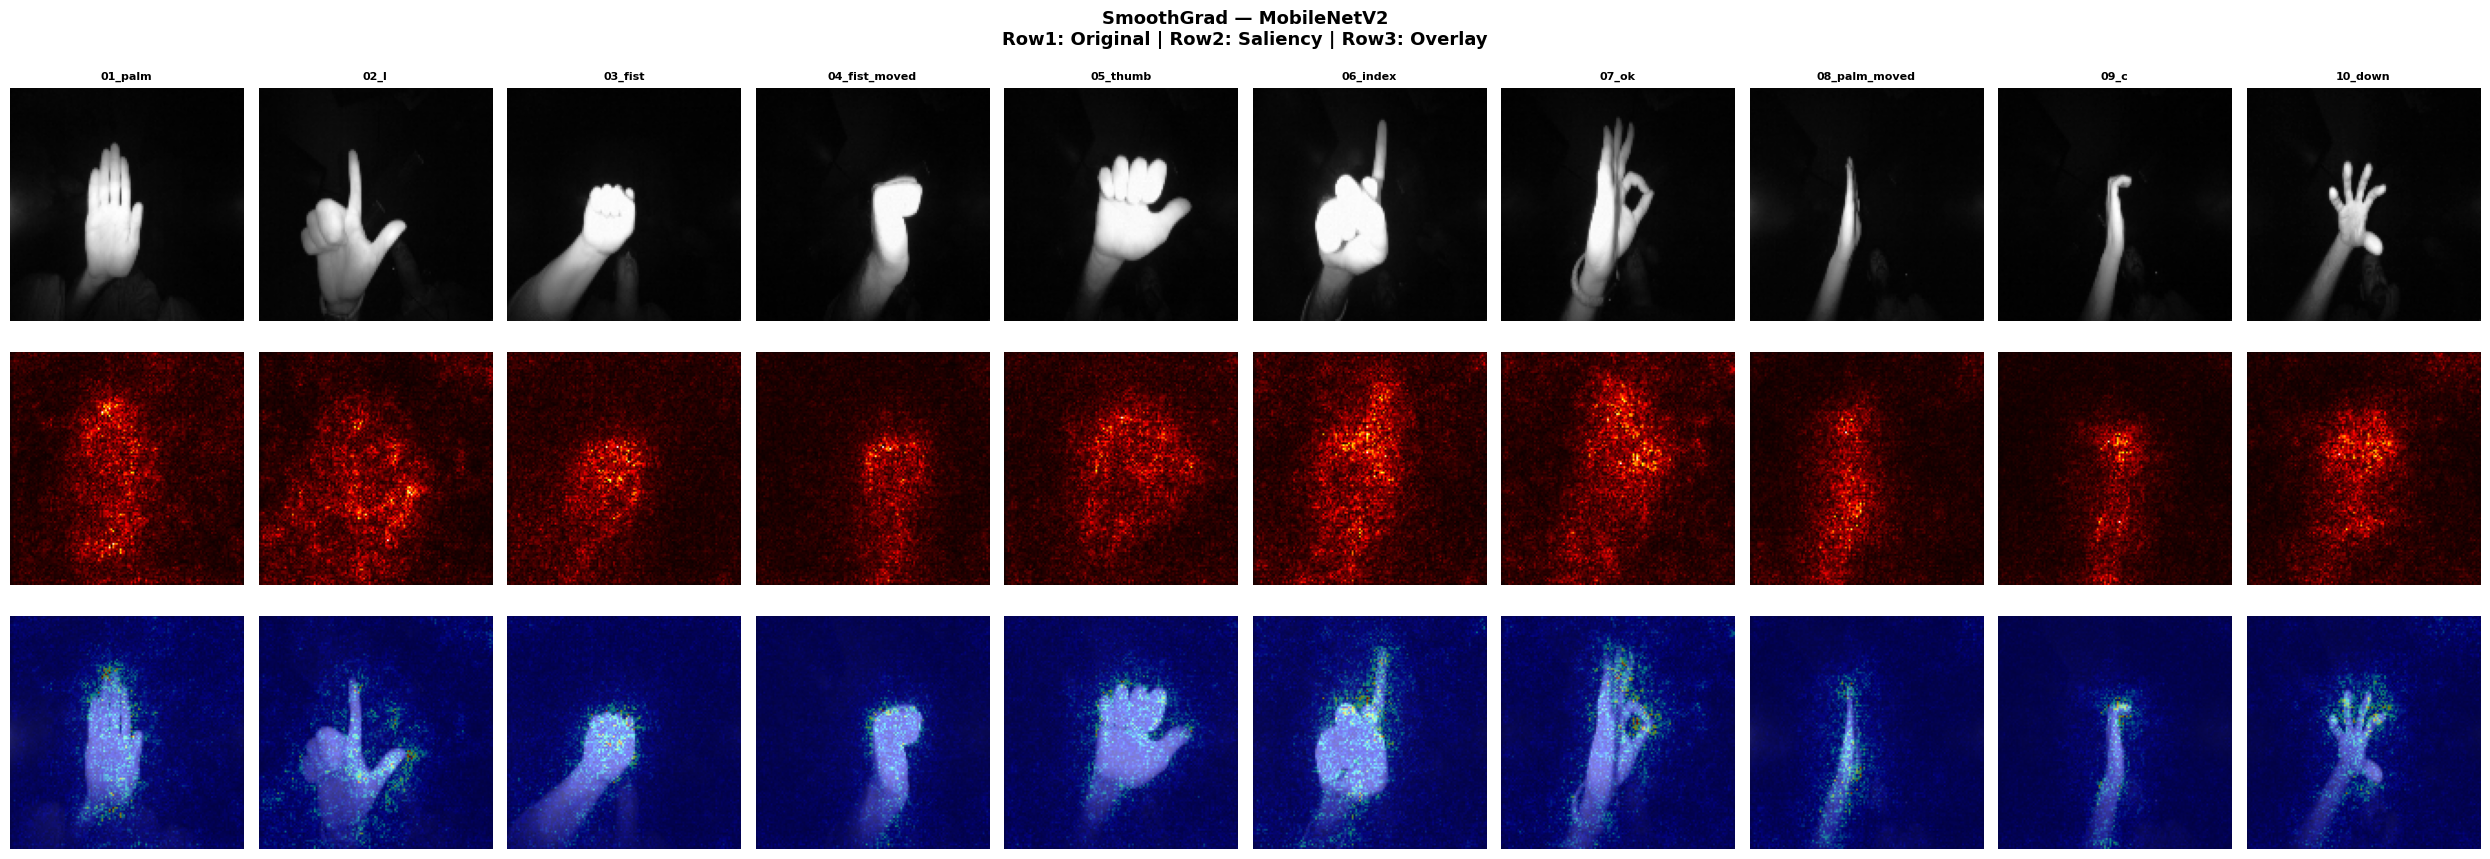

Saved: figures/gradcam_examples.png


In [3]:
# ── Saliency grid: one image per class ───────────────────────────────────────
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(NUM_CLASSES*2.5, 9))
fig.suptitle('SmoothGrad — MobileNetV2\nRow1: Original | Row2: Saliency | Row3: Overlay',
             fontsize=13, fontweight='bold')

for idx in range(NUM_CLASSES):
    correct = np.where((y_true==idx) & (y_pred_mob==idx))[0]
    if len(correct) == 0:
        correct = np.where(y_true==idx)[0]
    i = correct[0]
    img = X_test_rgb[i]
    try:
        sal = make_saliency_map(img[np.newaxis], mobilenet_model, pred_index=idx, n_samples=20)
        ovl = overlay_heatmap(img, sal)
    except Exception as e:
        print(f'Class {idx}: {e}')
        sal = np.zeros((128,128))
        ovl = np.uint8(img*255)

    axes[0,idx].imshow(img[:,:,0], cmap='gray'); axes[0,idx].set_title(CLASS_NAMES[idx], fontsize=8, fontweight='bold'); axes[0,idx].axis('off')
    axes[1,idx].imshow(sal, cmap='hot');         axes[1,idx].axis('off')
    axes[2,idx].imshow(ovl);                     axes[2,idx].axis('off')

plt.tight_layout()
plt.savefig('figures/gradcam_examples.png', dpi=150)
plt.show()
print('Saved: figures/gradcam_examples.png')


Misclassified: 2 / 3000 (0.1%)


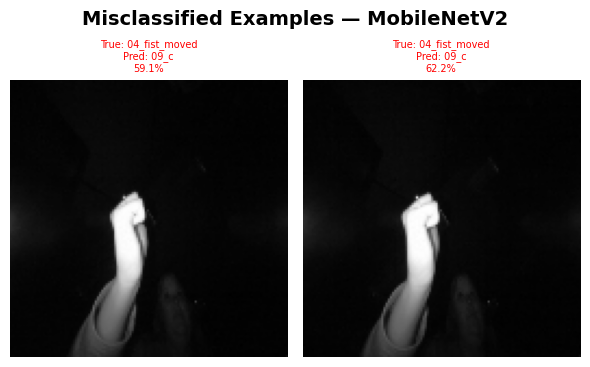

Saved: figures/misclassified_examples.png
All done!


In [4]:
# ── Error Analysis: Misclassified examples ────────────────────────────────────
wrong_idx = np.where(y_true != y_pred_mob)[0]
print(f'Misclassified: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)')

n_show = min(15, len(wrong_idx))
if n_show == 0:
    print('Perfect accuracy — no misclassified examples!')
else:
    sample = np.random.choice(wrong_idx, n_show, replace=False)
    cols = min(5, n_show)
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3+1))
    axes = np.array(axes).flatten()
    fig.suptitle('Misclassified Examples — MobileNetV2', fontsize=14, fontweight='bold')
    for ax, wi in zip(axes, sample):
        ax.imshow(X_test_rgb[wi,:,:,0], cmap='gray')
        conf = y_prob_mob[wi, y_pred_mob[wi]] * 100
        ax.set_title(f'True: {CLASS_NAMES[y_true[wi]]}\nPred: {CLASS_NAMES[y_pred_mob[wi]]}\n{conf:.1f}%',
                     fontsize=7, color='red')
        ax.axis('off')
    for ax in axes[n_show:]: ax.axis('off')
    plt.tight_layout()
    plt.savefig('figures/misclassified_examples.png', dpi=150)
    plt.show()
    print('Saved: figures/misclassified_examples.png')

print('All done!')
